In [1]:
import cv2 as cv 
import numpy as np 
import matplotlib.pyplot as plt

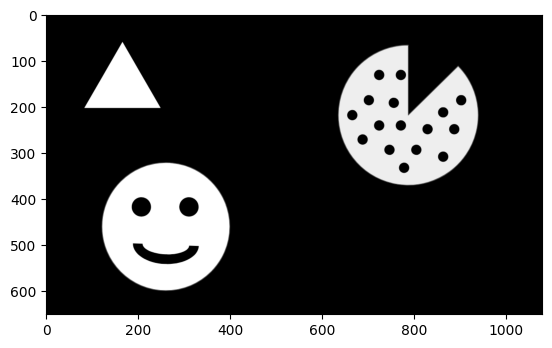

In [4]:
img = cv.imread("../data/internal_external.png")
plt.imshow(img)

In [5]:
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [7]:
# RETR_CCOMP: retrieves all of the contours and organizes them into a two-level hierarchy. 
# External contours of the object (boundary) are placed in hierarchy-1,
#  and the contours of holes (if any) are placed in hierarchy-2. 
# If there is another contour inside a hole, it is placed back in hierarchy-1.
# CHAIN_APPROX_SIMPLE: compresses horizontal, vertical, and diagonal segments and leaves only their end points.
contours , hierarchy = cv.findContours(img, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE) 
len(contours)

22

In [8]:
hierarchy.shape

(1, 22, 4)

Draw the contour 

In [9]:
external_contours = np.zeros(img.shape, dtype=np.uint8) # create a blank image to draw the external contours having the same shape as the original image
for i in range(len(contours)):
    if hierarchy[0][i][3] == -1: # check if the contour is external (has no parent contour)
        cv.drawContours(external_contours, contours, i, 255, -1) # draw the external contour on the blank image

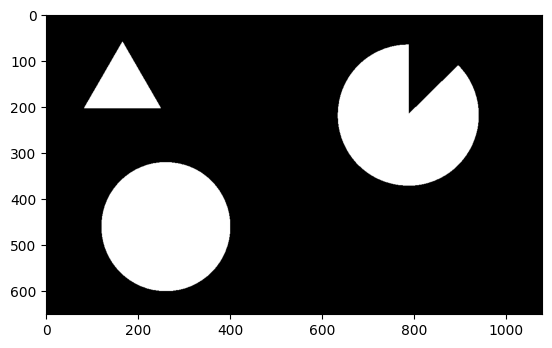

In [10]:
plt.imshow(external_contours, cmap="gray")

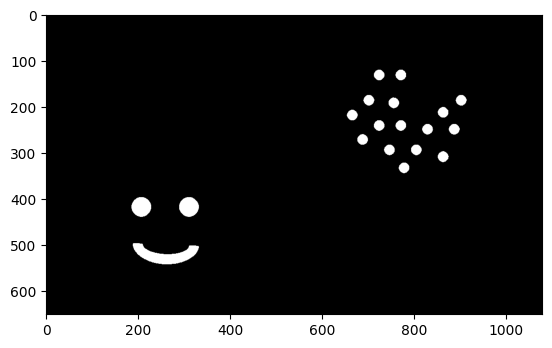

In [11]:
internal_contours = np.zeros(img.shape, dtype=np.uint8) # create a blank image to draw the internal contours having the same shape as the original image
for i in range(len(contours)):
    if hierarchy[0][i][3] != -1: # check if the contour is internal (has a parent contour)
        cv.drawContours(internal_contours, contours, i, 255, -1) # draw the internal contour on the blank image

plt.imshow(internal_contours, cmap="gray")        